# CKN: from Ca²⁺ signalling to redox-responsive proteins

This tutorial follows case study 2 of the
[SKM publication](https://doi.org/10.1016/j.xplc.2024.100920), with the Comprehensive
Knowledge Network (CKN):

> Arabidopsis rosettes were treated with H₂O₂, with or without the Ca²⁺ channel inhibitor
> LaCl₃, and their proteomes compared. Some proteins responded to H₂O₂ only when Ca²⁺
> signalling could take place: *Ca²⁺-dependent redox-responsive* proteins. How could Ca²⁺
> signalling reach them?

Along the way, it shows how to:

- load CKN and filter it by species, tissue and edge reliability (rank),
- add experimental data (logFC and p-values) to the nodes,
- find nodes by MapMan bin, and shortest paths between groups of nodes,
- find minimum cuts,
- translate the network to another species (here potato),
- convert the results to JSON,
- show the results in Cytoscape, with charts of the data on the nodes.

The Cytoscape cells (the last section) need a running Cytoscape; everything else runs
without it.

CKN is updated with new releases, so the results printed by the cells can differ from the
text. The `assert` lines check what holds whatever the network contains.

In [1]:
import json
import logging
from collections import Counter
from pathlib import Path

import networkx as nx
import pandas as pd

from skm_tools.annotations import get_nodes_by_mapman
from skm_tools.ckn import ckn_to_networkx, filter_ckn_edges, filter_ckn_nodes, rank_counts
from skm_tools.cuts import get_cutset
from skm_tools.experimental_data import add_experimental_data
from skm_tools.paths import get_paths, path_subgraph
from skm_tools.serialize import graph_to_dict, paths_to_dict
from skm_tools.translate import integrate_translation_ckn, load_translation_file

data_dir = Path("data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# the proteomics data of the case study, from the publication folder of this repository
proteomics_file = Path("../publication/case-study-2/data/merged-proteomics-data.tsv")

# show the messages of the skm-tools functions (e.g. what a filter removed)
logging.basicConfig(level="INFO", format="%(levelname)s %(name)s: %(message)s")

## Loading CKN

CKN is downloaded from [skm.nib.si](https://skm.nib.si) the first time, into `data/`
(about 4 MB). Undirected edges (e.g. binding) are added in both directions, so that
directed path searches can use them either way.

In [2]:
ckn = ckn_to_networkx(data_dir=data_dir)
print(ckn)

DiGraph with 26234 nodes and 898887 edges


Node types are the PSS classes; genes and RNAs also have their TAIR locus type:

In [3]:
Counter(d["node_type"] for _, d in ckn.nodes(data=True))

Counter({'PlantCoding': 24304,
         'PlantNonCoding': 1610,
         'Metabolite': 123,
         'PlantPseudogene': 122,
         'Complex': 49,
         'ForeignCoding': 10,
         'Process': 8,
         'ForeignNonCoding': 3,
         'ForeignAbiotic': 3,
         'ForeignEntity': 2})

In [4]:
ckn.nodes["AT2G38470"]

{'node_type': 'PlantCoding',
 'locus_type': 'protein_coding',
 'species': 'ath',
 'TAIR': 'AT2G38470',
 'display_label': 'WRKY33',
 'short_name': 'WRKY33',
 'synonyms': ['WRKY DNA-binding protein 33',
  'WRKY DNA-BINDING PROTEIN 33',
  'ATWRKY33',
  'WRKY33'],
 'description': 'WRKY DNA-binding protein 33',
 'mapman': ['14.5.7.5.1_RNA biosynthesis.DNA-binding transcriptional regulation.beta-hairpin exposed by alpha/beta-scaffold structure.WRKY transcription factor activity.transcription factor *(WRKY)',
  '26.11.3.2.1_External stimuli response.pathogen.defense mechanisms.WRKY33-dependent plant immunity.transcription factor *(WRKY33)'],
 'note': None,
 'tissue': ['seed', 'root', 'leaf', 'stem', 'flower']}

## Filtering

The experiment is on Arabidopsis leaves, so we keep only Arabidopsis nodes (pathogens and
abiotic stresses are `foreign`; nodes without a species, e.g. metabolites, are kept), and
genes known to be present in leaves (or without tissue information, `not assigned`):

In [5]:
removed = filter_ckn_nodes(ckn, species=["ath"], tissues=["leaf", "not assigned"])
assert all(d["species"] in ("ath", None) for _, d in ckn.nodes(data=True))
Counter(removed.values())

INFO skm_tools.ckn: Removed 1849 nodes from the network.


Counter({'wrong tissue type': 1690,
         'isolate': 133,
         'wrong species': 24,
         'complex component removed': 2})

Edges have a *rank*, from 0 (curated, from PSS) to 4 (only predicted). We keep ranks 0 to 2:
experimentally supported interactions.

In [6]:
rank_counts(ckn)

{0: 2416, 1: 33830, 2: 61106, 3: 657126, 4: 67425}

In [7]:
removed_edges, removed_nodes = filter_ckn_edges(ckn, keep_edge_ranks=[0, 1, 2])
assert set(rank_counts(ckn)) == {0, 1, 2, 3, 4} and rank_counts(ckn)[3] == rank_counts(ckn)[4] == 0
print(ckn)

INFO skm_tools.ckn: Removed 724551 edges and 11849 nodes from the network.


DiGraph with 12536 nodes and 97352 edges


## The proteomics data

The table has a row per protein (Arabidopsis gene id), with the logFC, p-value and
significance of four comparisons (mock or LaCl₃ pre-treatment; H₂O₂ for 10 or 30 minutes),
and which proteins are Ca²⁺-dependent redox-responsive:

In [8]:
proteomics = pd.read_csv(proteomics_file, sep="\t", index_col=0)
logfc_columns = [c for c in proteomics.columns if c.endswith("log-FC")]
logfc_columns

['Mock|Mock vs Mock|H2O2 (10 min) log-FC',
 'La3+|Mock vs La3+|H2O2 (10 min) log-FC',
 'Mock|Mock vs Mock|H2O2 (30 min) log-FC',
 'La3+|Mock vs La3+|H2O2 (30 min) log-FC']

In [9]:
responsive = proteomics[proteomics["responsiveness"].notna()]
responsive_in_ckn = [p for p in responsive.index if p in ckn]
print(len(responsive), "responsive proteins,", len(responsive_in_ckn), "in the filtered CKN")

59 responsive proteins, 41 in the filtered CKN


<div class="alert alert-info">

**A subset, to keep this tutorial fast.** Searching paths from every Ca²⁺-related gene to
every responsive protein takes several minutes. Here we use only the 10 proteins with the
largest change after 10 minutes of H₂O₂; for the full analysis, use `responsive_in_ckn`.

</div>

In [10]:
mock_10min = "Mock|Mock vs Mock|H2O2 (10 min) log-FC"
targets = (proteomics.loc[responsive_in_ckn, mock_10min].abs()
           .sort_values(ascending=False).index[:10].tolist())
assert len(targets) == min(10, len(responsive_in_ckn))
targets

['AT1G45201',
 'AT3G07660',
 'AT1G13750',
 'AT1G29690',
 'AT3G07630',
 'AT3G10340',
 'AT3G53260',
 'AT4G30490',
 'AT2G30520',
 'AT5G01600']

## Ca²⁺-related genes

The path searches start from the genes in MapMan bin 27.8, *Multi-process
regulation. calcium homeostasis* (MapMan4), including its sub-bins:

In [11]:
sources = get_nodes_by_mapman(ckn, "27.8")
print(len(sources), "genes in bin 27.8")

80 genes in bin 27.8


## Shortest paths

For each target, the shortest paths from the sources. With `shortest_overall=True`, only
the paths as short as the shortest from *any* source are kept, so each target is reached
by its closest Ca²⁺-related genes.

In [12]:
paths = get_paths(ckn, sources, targets, shortest_overall=True)
for p in paths:
    assert p[0] in sources and p[-1] in targets
    # each target is reached only by the paths as short as its shortest
    assert len(p) == min(len(q) for q in paths if q[-1] == p[-1])
print(len(paths), "paths; edges per path:", dict(Counter(len(p) - 1 for p in paths)))

label = dict(ckn.nodes(data="display_label"))
for p in paths[:5]:
    print(" → ".join(label[n] for n in p))

96 paths; edges per path: {3: 60, 4: 22, 2: 14}
CBL9 → AGL20 → LFY3 → TLL1
CAM4 → AGL8 → LFY3 → TLL1
CAM8 → AGL8 → LFY3 → TLL1
AT3G03000 → TCP14 → LST8-1 → TOR → AT3G07660
AT3G03000 → TIFY8 → LST8-1 → TOR → AT3G07660


At the time of writing, most targets are reached in three steps. Ca²⁺ sensors (e.g. the
calcineurin B-like protein CBL9 and calmodulins) reach the targets mostly through
transcription factors (e.g. the MADS-box factors AGL20 and AGL8, then LFY3, for TLL1):
each path is a hypothesis of how the Ca²⁺ signal could change the target's level, to be
weighed by the evidence for its edges (`rank`, `interactionSources`).

In [13]:
paths_net = path_subgraph(ckn, paths)
print(paths_net)

DiGraph with 89 nodes and 119 edges


## Minimum cuts

Which interactions does the Ca²⁺ signal have to pass on its way to the targets? The
minimum cut is the smallest set of edges whose removal disconnects the sources from the
targets. Each edge counts as 1 (`capacity`). The sources are the Ca²⁺-related genes the
paths start from:

In [14]:
nx.set_edge_attributes(paths_net, 1, "capacity")
path_sources = list(dict.fromkeys(p[0] for p in paths))
cut = get_cutset(paths_net, path_sources, targets)

# it is a cut: without these edges, no target can be reached from the sources
uncut = paths_net.copy()
uncut.remove_edges_from(cut)
only_targets = set(targets) - set(path_sources)  # a node that is both is not cut off from itself
assert not any(nx.has_path(uncut, s, t) for s in path_sources for t in only_targets)
[(label[u], label[v]) for u, v in cut]

INFO skm_tools.cuts: max_flow = 21


[('KFB01', 'PAL4'),
 ('KFB01', 'PAL2'),
 ('TYRA2', 'ADT2'),
 ('TOR', 'AT3G07660'),
 ('BRL2', 'PAP1'),
 ('PAL1', 'PAL4'),
 ('WRKY33', 'CAD1'),
 ('TTL3', 'RPT2'),
 ('PIF4', 'FER1'),
 ('VDAC1', 'AT4G30490'),
 ('MYB83', 'PAL4'),
 ('HAT22', 'PAP1'),
 ('HAT22', 'AT4G30490'),
 ('MYB4', 'PAL2'),
 ('HB30', 'PAL4'),
 ('ADT5', 'PAL2'),
 ('ERF9', 'PAL4'),
 ('ERF2', 'PAL4'),
 ('REV', 'PAL4'),
 ('EXO70E2', 'AT4G30490'),
 ('LFY3', 'TLL1')]

At the time of writing, every cut edge ends in a target: the paths share no bottleneck
upstream, each target is reached through its own regulators (several for PAL4, PAL2 and
AT4G30490). So the Ca²⁺ signal could reach these proteins in many ways; the edges into
the targets are where to look first (e.g. by checking their evidence).

## Adding the proteomics data

`add_experimental_data` returns a copy of the network with the data of each node as node
attributes; `prefix` keeps the attributes of different comparisons apart:

In [15]:
with_data = paths_net
for column in logfc_columns:
    comparison = column.removesuffix(" log-FC")
    with_data = add_experimental_data(with_data, proteomics, column, f"{comparison} p-value",
                                      prefix=f"{comparison} ")

# the attributes are <prefix>logFC, <prefix>pvalue and <prefix>significant
mock = "Mock|Mock vs Mock|H2O2 (10 min) "
for n in targets:
    d = with_data.nodes[n]
    assert d[f"{mock}significant"] == (d[f"{mock}pvalue"] is not None and d[f"{mock}pvalue"] <= 0.05)
pd.DataFrame.from_dict(dict(with_data.nodes(data=True)), orient="index").loc[
    targets, ["display_label", f"{mock}logFC", f"{mock}pvalue", f"{mock}significant"]
]

INFO skm_tools.experimental_data: 7 identifiers are in df more than once; the most significant row is used.


INFO skm_tools.experimental_data: Added data to 31 of 89 nodes.


INFO skm_tools.experimental_data: 7 identifiers are in df more than once; the most significant row is used.


INFO skm_tools.experimental_data: Added data to 31 of 89 nodes.


INFO skm_tools.experimental_data: 7 identifiers are in df more than once; the most significant row is used.


INFO skm_tools.experimental_data: Added data to 31 of 89 nodes.


INFO skm_tools.experimental_data: 7 identifiers are in df more than once; the most significant row is used.


INFO skm_tools.experimental_data: Added data to 31 of 89 nodes.


,display_label,Mock|Mock vs Mock|H2O2 (10 min) logFC,Mock|Mock vs Mock|H2O2 (10 min) pvalue,Mock|Mock vs Mock|H2O2 (10 min) significant
AT1G45201,TLL1,3.21794,0.00001,True
AT3G07660,AT3G07660,-1.93634,0.00003,True
AT1G13750,PAP1,-1.52586,0.00806,True
AT1G29690,CAD1,-1.37140,0.00259,True
AT3G07630,ADT2,-1.34952,NaN,False
AT3G10340,PAL4,-1.27660,0.03044,True
AT3G53260,PAL2,-1.27660,0.03044,True
AT4G30490,AT4G30490,-1.20606,0.01287,True
AT2G30520,RPT2,-1.20098,0.01067,True
AT5G01600,FER1,-1.16390,NaN,False


## Translating to potato

The SKM translation tables link Arabidopsis genes to their homologues in other species.
`integrate_translation_ckn` replaces each Arabidopsis gene by its potato homologues
(keeping all of them, as translations can be many-to-many), with the edges copied:

In [16]:
potato = load_translation_file("stu", data_dir=data_dir)
potato.head()

,ath_source,potato,symbol_source,filter_criteria,evidence
0,AT1G01020,Soltu.DM.11G003840,ARV1,compara,"FastOMA,OrthoDB,PLAZA,compara,MapMan4_Match"
1,AT1G01030,Soltu.DM.08G005020,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
2,AT1G01030,Soltu.DM.08G005030,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
3,AT1G01030,Soltu.DM.08G030310,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
4,AT1G01040,Soltu.DM.10G000330,DCL1,compara,"FastOMA,OrthoDB,RBH,compara,MapMan4_Match"


In [17]:
paths_net_potato = integrate_translation_ckn(paths_net, potato, t_target_col="potato")
print(paths_net_potato)

MultiDiGraph with 208 nodes and 1723 edges


Translated nodes have the attributes `translated_from` (the Arabidopsis node) and
`translation` (the potato gene); Arabidopsis genes without a potato homologue in the
translation table are kept, with `translated` False. How many potato genes does each
Arabidopsis gene on the paths have?

In [18]:
translated = [d for _, d in paths_net_potato.nodes(data=True) if d.get("translated")]
assert all(d["translated_from"] in paths_net for d in translated)

homologues = Counter(d["translated_from"] for d in translated)
print(len(homologues), "Arabidopsis genes with potato homologues; genes with 1, 2, ... homologues:",
      dict(sorted(Counter(homologues.values()).items())))
print("No potato homologue:", ", ".join(label[n] for n, d in paths_net_potato.nodes(data=True)
                                         if d.get("translated") is False))

83 Arabidopsis genes with potato homologues; genes with 1, 2, ... homologues: {1: 34, 2: 24, 3: 12, 4: 5, 5: 2, 6: 1, 7: 1, 8: 2, 10: 1, 15: 1}
No potato homologue: CAM4, CAM7, MSS3, CAM6, TYRA2, CIPK9


The first path, in potato: the potato genes of each step (any of them could take the
step's role in potato):

In [19]:
for n in paths[0]:
    genes = [d["translation"] for d in translated if d["translated_from"] == n]
    print(f"{label[n]:8}", ", ".join(genes) or "(no potato homologue)")

CBL9     Soltu.DM.06G018290, Soltu.DM.08G001090, Soltu.DM.08G023660
AGL20    PGSC0003DMG400010263, Soltu.DM.01G032700, Soltu.DM.01G032710, Soltu.DM.01G032720, Soltu.DM.10G006870
LFY3     Soltu.DM.03G032420
TLL1     Soltu.DM.04G033550


## Converting to JSON

For other tools (or languages), networks and paths can be converted to plain,
JSON-serialisable data:

In [20]:
with open(output_dir / "ckn-ca-paths.json", "w") as handle:
    json.dump({"network": graph_to_dict(with_data), "paths": paths_to_dict(paths, ckn)}, handle)

paths_to_dict(paths[:1], ckn)

{'paths': [['AT5G47100', 'AT2G45660', 'AT5G61850', 'AT1G45201']],
 'lengths': [3],
 'nodes': {'AT5G47100': {'display_label': 'CBL9'},
  'AT2G45660': {'display_label': 'AGL20'},
  'AT5G61850': {'display_label': 'LFY3'},
  'AT1G45201': {'display_label': 'TLL1'}},
 'steps': [[{'source': 'AT5G47100',
    'target': 'AT2G45660',
    'interaction': 'unknown-influence'},
   {'source': 'AT2G45660',
    'target': 'AT5G61850',
    'interaction': 'positive-influence'},
   {'source': 'AT5G61850',
    'target': 'AT1G45201',
    'interaction': 'positive-influence'}]]}

## Cytoscape

The rest of this tutorial needs a running Cytoscape (3.10 or later), the `cytoscape` extra
(`pip install "skm-tools[cytoscape]"`), and the
[enhancedGraphics](https://apps.cytoscape.org/apps/enhancedgraphics) app for the charts.
We show the path network with the SKM style, the logFC of the four comparisons as a bar
chart on each node, and the cut edges highlighted.

In [21]:
# ci-skip: needs a running Cytoscape
import py4cytoscape as p4c
from IPython.display import Image

from skm_tools import cytoscape_utils as cu

p4c.cytoscape_ping()

DEBUG py4...: Calling cytoscape_ping()


DEBUG py4...: ǀCalling cytoscape_version_info(base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('version', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: Attempting to direct connect to Cytoscape on http://127.0.0.1:1234/v1


DEBUG py4...: Detected py4cytoscape running on Cytoscape workstation


...

DEBUG py4...: ǀǀReturning 'cyrest_get': {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.2'}


DEBUG py4...: ǀReturning 'cytoscape_version_info': {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.2', 'automationAPIVersion': '1.13.0', 'py4cytoscapeVersion': '1.13.0'}


DEBUG py4...: Returning 'cytoscape_ping': 'You are connected to Cytoscape!'


DEBUG py4...: --------------------


'You are connected to Cytoscape!'

In [22]:
# ci-skip: needs a running Cytoscape
suid = cu.load_network(with_data, title="Ca2+ paths", collection="Tutorial: CKN", style="skm")
p4c.layout_network("force-directed", network=suid)

DEBUG py4...: Calling create_network_from_networkx(<networkx.classes.digraph.DiGraph object at 0x7f7d17d35220>, title='Ca2+ paths', collection='Tutorial: CKN')


DEBUG py4...: ǀCalling create_network_from_data_frames(nodes=      node_type      locus_type species       TAIR display_label short_name  \
0   PlantCoding  protein_coding     ath  AT5G15210          HB30       HB30   
1   PlantCoding  protein_coding     ath  AT4G17615        SCABP5     SCABP5   
2   PlantCoding  protein_coding     ath  AT1G29690          CAD1       CAD1   
3   PlantCoding  protein_coding     ath  AT5G24270          SOS3       SOS3   
4   PlantCoding  protein_coding     ath  AT1G15670         KFB01      KFB01   
..          ...             ...     ...        ...           ...        ...   
84  PlantCoding  protein_coding     ath  AT3G15170          CUC1       CUC1   
85  PlantCoding  protein_coding     ath  AT3G08730           PK1        PK1   
86  PlantCoding  protein_coding     ath  AT3G03450          RGL2       RGL2   
87  PlantCoding  protein_coding     ath  AT3G18140        LST8-1     LST8-1   
88  PlantCoding  protein_coding     ath  AT1G13750          PAP1      

DEBUG py4...: ǀǀCalling cyrest_post('networks', parameters={'title': 'Ca2+ paths', 'collection': 'Tutorial: CKN'}, body={'data': [{'name': 'Ca2+ paths'}], 'elements': {'nodes': [{'data': {'id': 'AT5G15210'}}, {'data': {'id': 'AT4G17615'}}, {'data': {'id': 'AT1G29690'}}, {'data': {'id': 'AT5G24270'}}, {'data': {'id': 'AT1G15670'}}, {'data': {'id': 'AT1G48260'}}, {'data': {'id': 'AT1G66410'}}, {'data': {'id': 'AT5G60690'}}, {'data': {'id': 'AT5G47100'}}, {'data': {'id': 'AT5G47220'}}, {'data': {'id': 'AT2G43010'}}, {'data': {'id': 'AT1G22920'}}, {'data': {'id': 'AT1G71930'}}, {'data': {'id': 'AT2G37040'}}, {'data': {'id': 'AT5G60910'}}, {'data': {'id': 'AT5G22630'}}, {'data': {'id': 'AT3G47620'}}, {'data': {'id': 'AT3G43810'}}, {'data': {'id': 'AT2G30360'}}, {'data': {'id': 'AT5G07070'}}, {'data': {'id': 'AT2G45660'}}, {'data': {'id': 'AT5G38480'}}, {'data': {'id': 'AT5G45820'}}, {'data': {'id': 'AT2G01950'}}, {'data': {'id': 'AT3G08500'}}, {'data': {'id': 'AT3G62420'}}, {'data': {'id': 

DEBUG py4...: ǀǀHTTP POST(http://127.0.0.1:1234/v1/networks), params: {'title': 'Ca2+ paths', 'collection': 'Tutorial: CKN'}, json: {'data': [{'name': 'Ca2+ paths'}], 'elements': {'nodes': [{'data': {'id': 'AT5G15210'}}, {'data': {'id': 'AT4G17615'}}, {'data': {'id': 'AT1G29690'}}, {'data': {'id': 'AT5G24270'}}, {'data': {'id': 'AT1G15670'}}, {'data': {'id': 'AT1G48260'}}, {'data': {'id': 'AT1G66410'}}, {'data': {'id': 'AT5G60690'}}, {'data': {'id': 'AT5G47100'}}, {'data': {'id': 'AT5G47220'}}, {'data': {'id': 'AT2G43010'}}, {'data': {'id': 'AT1G22920'}}, {'data': {'id': 'AT1G71930'}}, {'data': {'id': 'AT2G37040'}}, {'data': {'id': 'AT5G60910'}}, {'data': {'id': 'AT5G22630'}}, {'data': {'id': 'AT3G47620'}}, {'data': {'id': 'AT3G43810'}}, {'data': {'id': 'AT2G30360'}}, {'data': {'id': 'AT5G07070'}}, {'data': {'id': 'AT2G45660'}}, {'data': {'id': 'AT5G38480'}}, {'data': {'id': 'AT5G45820'}}, {'data': {'id': 'AT2G01950'}}, {'data': {'id': 'AT3G08500'}}, {'data': {'id': 'AT3G62420'}}, {'da

DEBUG py4...: ǀǀOK[200], content: {"networkSUID":11420}


...

DEBUG py4...: ǀOK[200], content: {
 "data": {},
 "errors":[]
}


DEBUG py4...: ǀReturning 'commands_post': {}


DEBUG py4...: Returning 'layout_network': {}


DEBUG py4...: --------------------


{}

One bar per comparison: mock pre-treatment in red, LaCl₃ in blue. The charts go into a
node table column, which a copy of the style shows below the nodes:

In [23]:
# ci-skip: needs a running Cytoscape
colors = ["#E41A1C" if c.startswith("Mock") else "#377EB8" for c in logfc_columns]
charts = cu.chart_column(proteomics.loc[[n for n in with_data if n in proteomics.index]],
                         logfc_columns, colors, value_range=(-3, 3),
                         labels=["mock 10'", "La 10'", "mock 30'", "La 30'"])
p4c.load_table_data(charts.to_frame("logFC chart"), network=suid)

style = cu.copy_style("SKM", "SKM-proteomics", networks=[suid], overwrite=True)
cu.show_node_images(style, "logFC chart", size=60)
highlighted = cu.highlight_edges(cut, "#FF7F00", network=suid)

DEBUG py4...: Calling load_table_data(                                                  logFC chart
identifier                                                   
AT1G29690   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT1G66410   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT2G37040   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT5G22630   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT3G43810   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT5G38480   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT5G21274   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT4G30490   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT3G01280   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT3G56800   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT2G30520   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT1G35160   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT4G38810   barchart: colorlist="#E41A1C,#377EB8,#E41A1C,#...
AT3G07630   barchart: colorlist=

DEBUG py4...: ǀCalling get_network_suid(11420, base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('networks', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀHTTP GET(http://127.0.0.1:1234/v1/networks)


DEBUG py4...: ǀǀOK[200], content: [128,709,11094,555,268,11420,413]


...

DEBUG py4...: ǀǀOK[200], content: 


DEBUG py4...: ǀǀReturning 'cyrest_put': ''


DEBUG py4...: ǀReturning 'set_edge_property_bypass': ''


DEBUG py4...: Returning 'set_edge_color_bypass': ''


DEBUG py4...: --------------------


DEBUG py4...: Calling fit_content(network=11420)


DEBUG py4...: ǀCalling get_network_view_suid(11420, base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('networks', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀHTTP GET(http://127.0.0.1:1234/v1/networks)


DEBUG py4...: ǀǀOK[200], content: [128,709,11094,555,268,11420,413]


...

DEBUG py4...: ǀHTTP POST(http://127.0.0.1:1234/v1/commands/view/export%20png), json: {'allGraphicsDetails': 'True', 'Zoom': '150', 'outputFile': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-ca-paths.png', 'view': 'SUID:12312'}


DEBUG py4...: ǀOK[200], content: {
 "data": {"file":"/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-ca-paths.png"},
 "errors":[]
}


DEBUG py4...: ǀReturning 'commands_post': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-ca-paths.png'}


DEBUG py4...: Returning 'export_image': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-ca-paths.png'}


DEBUG py4...: --------------------


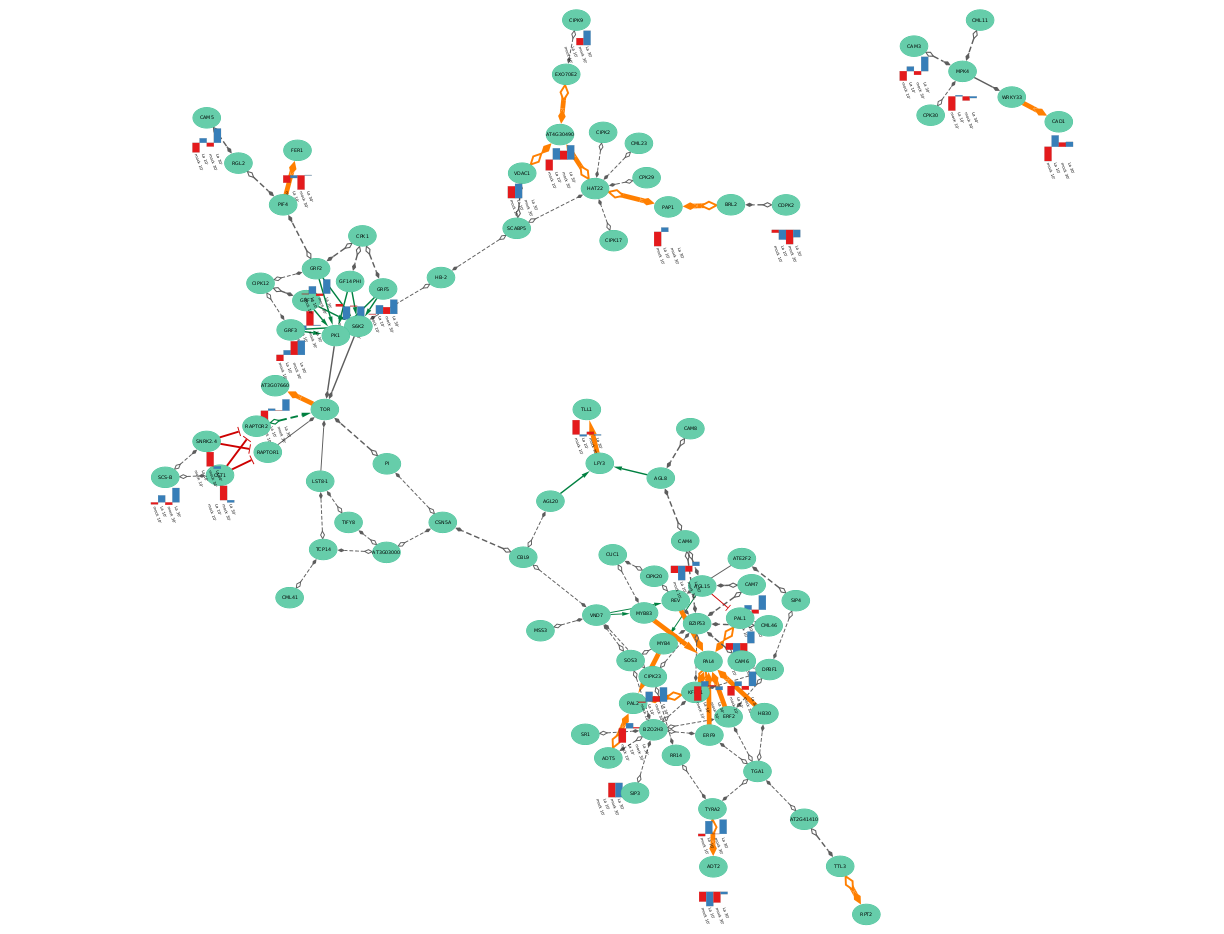

In [24]:
# ci-skip: needs a running Cytoscape
image = cu.export_network(output_dir / "ckn-ca-paths.png", format="PNG", zoom=150, network=suid)
Image(image)